In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load dataset
generation = pd.read_csv('smard_generation_2023.csv', sep = ';')
demand = pd.read_csv('smard_demand_2023.csv', sep = ';')

# look into dataset
#generation.head(10)
#demand.head(10)

# check dataset types
#generation.dtypes
#demand.dtypes

# convert to object to int
generation['Solar'] = generation['Photovoltaics [MWh] Calculated resolutions'].str.replace(',', '').astype(float)
generation['Wind offshore [MWh]'] = generation['Wind offshore [MWh] Calculated resolutions'].str.replace(',', '').astype(float)
generation['Wind onshore [MWh]'] = generation['Wind onshore [MWh] Calculated resolutions'].str.replace(',', '').astype(float)
demand['Grid load [MWh]'] = demand['grid load [MWh] Calculated resolutions'].str.replace(',', '').astype(float)

# calculate total wind generation
generation['Wind Total [MWh]'] = generation['Wind offshore [MWh]'] + generation['Wind onshore [MWh]']

# merge start dates
df = generation.merge(demand, on = 'Start date')

# calculate total renewable generation
df['renewable_total'] = df['Solar'] + df['Wind Total [MWh]']

# calc the diff between demand and generation, if demand is higher than generation, set to 0
df['surplus'] = (df['renewable_total'] - df['Grid load [MWh]']).clip(lower=0)

# True when surplus is greater than 0, False otherwise
df['curtailment_flag'] = df['surplus'] > 0
df['curtailment_flag'].value_counts()

# total curtailment in MWh
curtailed_energy = df['surplus'].sum()
print(curtailed_energy)
# convert ot TWh
print(curtailed_energy / 1e6, 'TWh')


# BATTERY SIZING
# max hourly surplus
max_hourly_surplus = df['surplus'].max()
print(max_hourly_surplus / 1e3, 'GWh')


# SUMMARY
print('Total curtaiment hours:', df['curtailment_flag'].value_counts()[True])
print('Total curtaiment energy:', curtailed_energy / 1e6, 'TWh')
print('Max hourly surplus:', max_hourly_surplus / 1e3, 'GWh')

# month extraction
df['month'] = pd.to_datetime(df['Start date']).dt.month_name()
df['month'].head()

109526.0
0.109526 TWh
5.647 GWh
Total curtaiment hours: 51
Total curtaiment energy: 0.109526 TWh
Max hourly surplus: 5.647 GWh


C:\Users\vpshr\AppData\Local\Temp\ipykernel_23084\2476147514.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['month'] = pd.to_datetime(df['Start date']).dt.month_name()


0    January
1    January
2    January
3    January
4    January
Name: month, dtype: object

In [21]:
import sqlite3

# create a real time memory db
conn = sqlite3.connect(':memory:')

#load the df into it as an actual table called grid_data
df.to_sql('grid_data', conn, index=False, if_exists = 'replace')

# count the number of curtailment hours in the database(true = count+)
result = pd.read_sql_query("SELECT COUNT(*) as curtailment_hours FROM grid_data WHERE curtailment_flag = 1", conn)
print(result)

# total cutrailed energy
result1 = pd.read_sql_query('SELECT SUM(surplus) as curtailed_energy FROM grid_data WHERE curtailment_flag = 1', conn)
print(result1)

#max hourly surplus - battery sizing number
result2 = pd.read_sql_query('SELECT MAX(surplus) as battery_sizing FROM grid_data', conn)
print(result2)

# summarize all 3
#final = pd.concat([result, result1, result2], axis=1) - pandas
final = pd.read_sql_query('SELECT COUNT(*) as curtailment_hours, SUM(surplus) as curtailed_energy, MAX(surplus) as battery_sizing FROM grid_data WHERE curtailment_flag = 1', conn)
print(final)
print(f"Curtailment hours: {final['curtailment_hours'][0]}")
print(f"Total curtailed energy: {final['curtailed_energy'][0] / 1e3:.1f} GWh")
print(f"Battery capacity needed: {final['battery_sizing'][0] / 1e3:.1f} GWh")

   curtailment_hours
0                 51
   curtailed_energy
0          109526.0
   battery_sizing
0          5647.0
   curtailment_hours  curtailed_energy  battery_sizing
0                 51          109526.0          5647.0
Curtailment hours: 51
Total curtailed energy: 109.5 GWh
Battery capacity needed: 5.6 GWh


In [44]:
# monthly aggregations
month_extract = pd.read_sql_query("SELECT month, SUM(Solar) as sum_of_solar, SUM(`Wind Total [MWh]`) as sum_of_wind, SUM(surplus) as sum_of_surplus, SUM(curtailment_flag) as curtailment_hours FROM grid_data GROUP BY month", conn)
print(month_extract)

        month  sum_of_solar  sum_of_wind  sum_of_surplus  curtailment_hours
0       April    5522118.25  10081697.00        24222.75                  6
1      August    6537509.25   6945442.25          984.25                  2
2    December     761045.00  19257932.25        15110.00                 14
3    February    2309490.25  12045978.50            0.00                  0
4     January     824251.50  17373583.25            0.00                  0
5        July    7693868.50  10153102.00        41859.50                 18
6        June    8904774.50   6042107.50         9083.75                  4
7       March    3735177.75  14513934.25            0.00                  0
8         May    8019121.75   8322297.50          974.75                  1
9    November    1367921.75  16731090.75            0.00                  0
10    October    3310222.00  14466495.50        17291.00                  6
11  September    6558575.00   6650590.00            0.00                  0


# VISUALIZATION

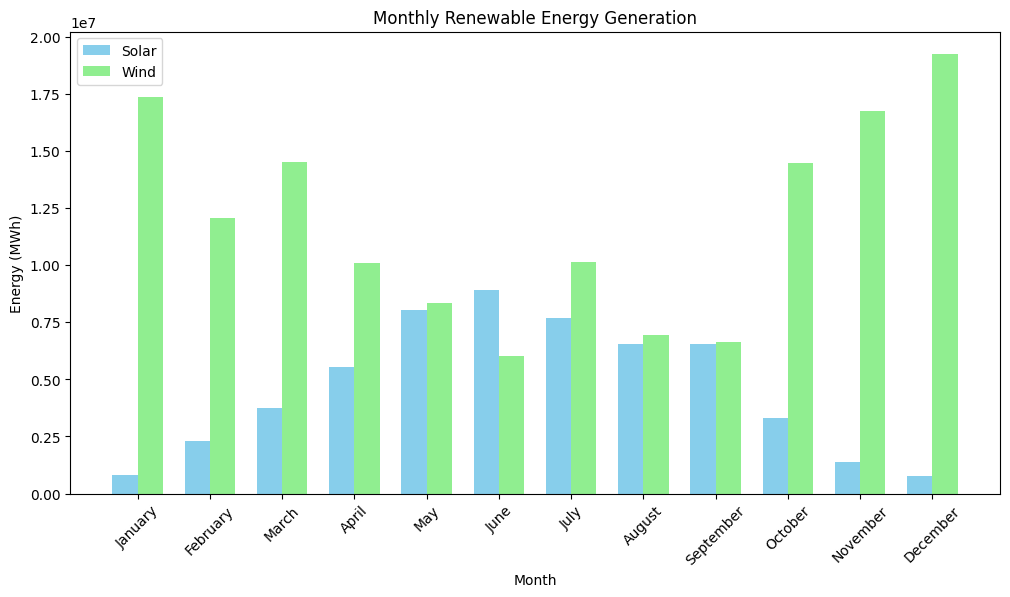

In [ ]:
# month sorting
month_order = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6, 'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
# map the dict with month col
month_extract['month_num'] = month_extract['month'].map(month_order)
month_extract = month_extract.sort_values('month_num')

x = np.arange(len(month_extract['month']))  # the label locations
width = 0.35
plt.figure(figsize=(12,6))
plt.bar(x - width/2, month_extract['sum_of_solar'], width, color='skyblue', label='Solar')
plt.bar(x + width/2, month_extract['sum_of_wind'], width, color='lightgreen', label='Wind')
plt.xticks(x, month_extract['month'], rotation = 45) # adjusts the label values, avoid clashes
plt.title('Monthly Renewable Energy Generation')
plt.xlabel('Month')
plt.ylabel('Energy (MWh)')
plt.legend()
plt.show()

C:\Users\vpshr\AppData\Local\Temp\ipykernel_23084\1388846337.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


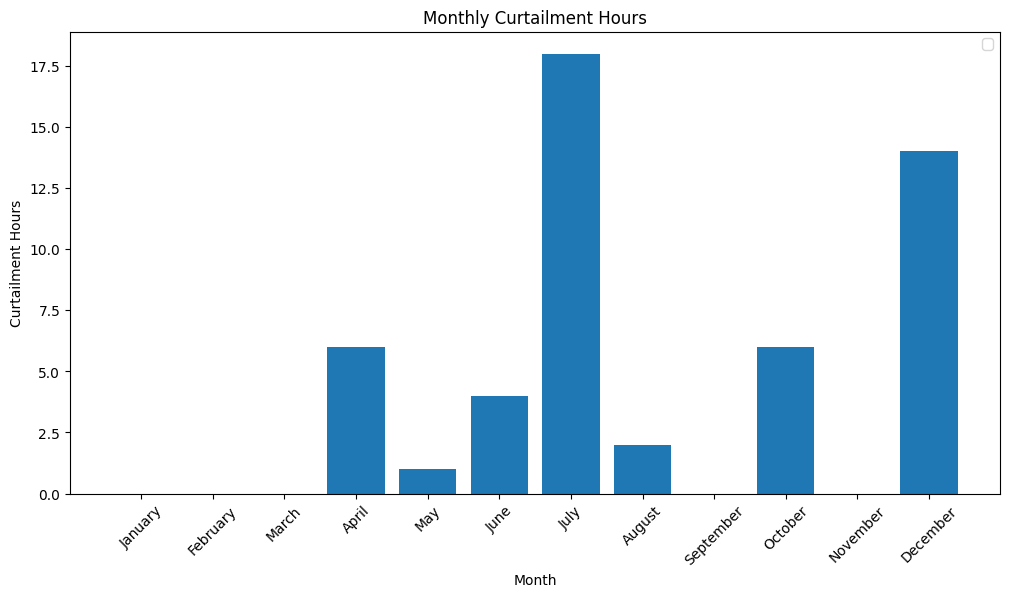

In [53]:
plt.figure(figsize=(12,6))
plt.bar(month_extract['month'], month_extract['curtailment_hours'])
plt.title('Monthly Curtailment Hours')
plt.xticks(x, month_extract['month'], rotation = 45)
plt.xlabel('Month')
plt.ylabel('Curtailment Hours')
plt.legend()
plt.show()

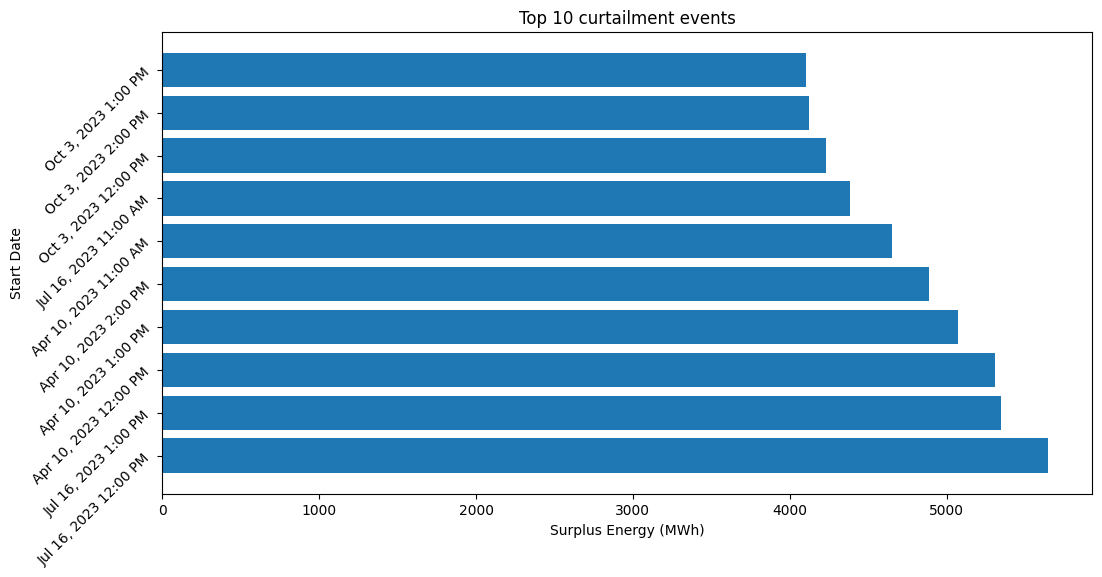

In [66]:
top10 = pd.read_sql_query("SELECT * FROM grid_data ORDER BY surplus DESC LIMIT 10", conn) 
top10.head()

plt.figure(figsize=(12,6))
plt.barh(top10['Start date'], top10['surplus'])
plt.title('Top 10 curtailment events')
plt.yticks(top10['Start date'], rotation = 45)
plt.xlabel('Surplus Energy (MWh)')
plt.ylabel('Start Date')
plt.show()
